Monte Carlo Configuration
  Number of Samples : 100
  Random Seed       : 42
Cleared 1 old image file(s) before regenerating.

Model Configuration
  Material          : Aluminium 6061-T6
  Joint Type        : Lap joint
  Weld Arrangement  : Double fillet weld on both longitudinal edges of the overlap
  Thermocouples     : ['TC1', 'TC2', 'TC3']
  TC Distances      : [2.0 5.0 10.0] mm

Nominal GMAW Conditions
  Voltage           : 22.0 V
  Current           : 180.0 A
  Travel Speed      : 8.0 mm/s
  Wire Feed Rate    : [7.0] m / min
  Efficiency        : 0.800

Monte Carlo Statistics
  Voltage      : mean=21.95 V, std=0.696 V
  Current      : mean=179.93 A, std=6.822 A
  Travel Speed : mean=7.9751 mm/s, std=0.4077 mm/s
  Sensor Noise : mean=0.205 degC, std=2.016 degC
  Net Power    : mean=3160.5 W, std=162.99 W
  Heat Input   : mean=397325 J/m, std=28755 J/m

Virtual thermocouple measurement chain defined:

Saved Monte Carlo distribution figure: mc_distributions.png

Monte Carlo Dataset 

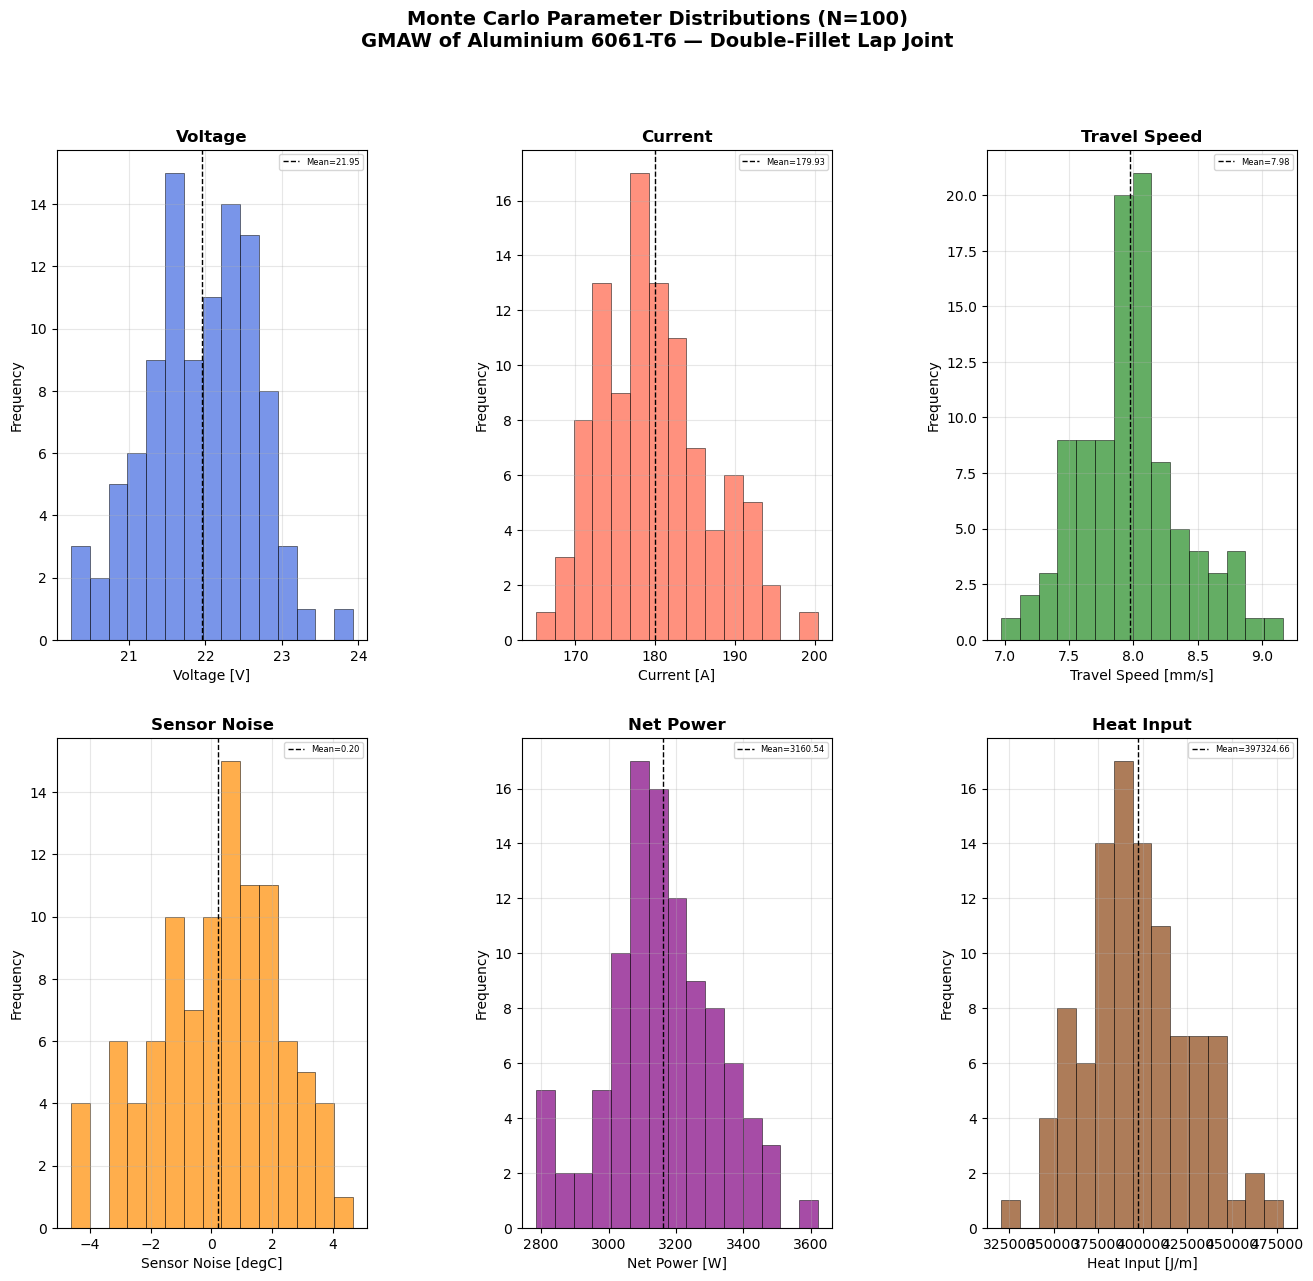

In [2]:
from pathlib import Path

CORE_FILE = "project_core.asdf"

if not Path(CORE_FILE).exists():
    raise FileNotFoundError(
        f"⚠ {CORE_FILE} not found. Run Tab 1 first!"
    )

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from weldx import WeldxFile, Q_, MathematicalExpression
from weldx.measurement import Error, MeasurementChain


# ============================================================
# MONTE CARLO CONFIGURATION — ORIGINAL SETTINGS RETAINED
# ============================================================
N_SAMPLES = 100
SEED = 42
rng = np.random.default_rng(SEED)

print("Monte Carlo Configuration")
print(f"  Number of Samples : {N_SAMPLES}")
print(f"  Random Seed       : {SEED}")


# ============================================================
# REMOVE OLD OUTPUT IMAGE
# ============================================================
old_images = ["mc_distributions.png"]
removed = 0

for image_name in old_images:
    image_path = Path(image_name)

    if image_path.exists():
        image_path.unlink()
        removed += 1

plt.close("all")
print(f"Cleared {removed} old image file(s) before regenerating.")


# ============================================================
# LOAD THE CORE MODEL CREATED IN TAB 1
# ============================================================
with WeldxFile(CORE_FILE, mode="r") as wx:
    core = wx.copy()

material_name = core["material"]["common_name"]
joint_type = core["geometry"]["joint_type"]
joint_configuration = core["geometry"]["joint_configuration"]

sensor_labels = core["geometry"].get(
    "sensor_labels",
    ["TC1", "TC2", "TC3"],
)

sensor_distances = core["geometry"].get(
    "thermo_distance",
    Q_([2.0, 5.0, 10.0], "mm"),
)


# ============================================================
# NOMINAL GMAW VALUES FROM CONFIG.YAML THROUGH TAB 1
# ============================================================
V_nom = float(core["process"]["voltage"].to("V").m)
I_nom = float(core["process"]["current"].to("A").m)
v_nom = float(core["process"]["speed"].to("mm/s").m)

efficiency_nom = float(
    core["process"]["efficiency"].to("dimensionless").m
)

wire_feed_nom = (
    core["gmaw_process"]
    .parameters["wire_feedrate"]
    .data
)

print("\nModel Configuration")
print(f"  Material          : {material_name}")
print(f"  Joint Type        : {joint_type}")
print(f"  Weld Arrangement  : {joint_configuration}")
print(f"  Thermocouples     : {sensor_labels}")
print(f"  TC Distances      : {sensor_distances}")

print("\nNominal GMAW Conditions")
print(f"  Voltage           : {V_nom:.1f} V")
print(f"  Current           : {I_nom:.1f} A")
print(f"  Travel Speed      : {v_nom:.1f} mm/s")
print(f"  Wire Feed Rate    : {wire_feed_nom}")
print(f"  Efficiency        : {efficiency_nom:.3f}")


# ============================================================
# MONTE CARLO SAMPLING — ORIGINAL DISTRIBUTIONS RETAINED
# ============================================================
# Voltage: nominal mean, standard deviation = 0.9 V
mc_voltage = rng.normal(
    loc=V_nom,
    scale=0.9,
    size=N_SAMPLES,
)

# Current: nominal mean, standard deviation = 7 A
mc_current = rng.normal(
    loc=I_nom,
    scale=7.0,
    size=N_SAMPLES,
)

# Travel speed: nominal mean, standard deviation = 0.4 mm/s
mc_speed = rng.normal(
    loc=v_nom,
    scale=0.4,
    size=N_SAMPLES,
)

# Sensor noise: mean = 0 degC, standard deviation = 2 degC
mc_sensor_noise = rng.normal(
    loc=0.0,
    scale=2.0,
    size=N_SAMPLES,
)


# ============================================================
# ORIGINAL CLIPPING LIMITS RETAINED
# ============================================================
mc_voltage = np.clip(mc_voltage, 16.0, 30.0)
mc_current = np.clip(mc_current, 120.0, 260.0)
mc_speed = np.clip(mc_speed, 3.0, 15.0)


# ============================================================
# DERIVED NET POWER AND HEAT INPUT
# ============================================================
mc_net_power = (
    mc_voltage
    * mc_current
    * efficiency_nom
)

mc_heat_input = (
    mc_net_power
    / (mc_speed * 1.0e-3)
)

print("\nMonte Carlo Statistics")

print(
    f"  Voltage      : mean={mc_voltage.mean():.2f} V, "
    f"std={mc_voltage.std():.3f} V"
)

print(
    f"  Current      : mean={mc_current.mean():.2f} A, "
    f"std={mc_current.std():.3f} A"
)

print(
    f"  Travel Speed : mean={mc_speed.mean():.4f} mm/s, "
    f"std={mc_speed.std():.4f} mm/s"
)

print(
    f"  Sensor Noise : mean={mc_sensor_noise.mean():.3f} degC, "
    f"std={mc_sensor_noise.std():.3f} degC"
)

print(
    f"  Net Power    : mean={mc_net_power.mean():.1f} W, "
    f"std={mc_net_power.std():.2f} W"
)

print(
    f"  Heat Input   : mean={mc_heat_input.mean():.0f} J/m, "
    f"std={mc_heat_input.std():.0f} J/m"
)


# ============================================================
# VIRTUAL THERMOCOUPLE MEASUREMENT CHAIN
# ============================================================
tc_chain = MeasurementChain.from_parameters(
    name="Virtual Thermocouple Chain (TC1/TC2/TC3)",
    source_name=(
        "Type-K thermocouple junctions at "
        "2 mm, 5 mm and 10 mm from Weld 1"
    ),
    source_error=Error(
        deviation=Q_(2.0, "delta_degC")
    ),
    output_signal_type="analog",
    output_signal_unit="mV",
)

tc_chain.create_transformation(
    name="AD conversion",
    error=Error(
        deviation=Q_(0.0, "percent")
    ),
    output_signal_type="digital",
    output_signal_unit="",
)

tc_chain.create_transformation(
    name="Type-K calibration",
    error=Error(
        Q_(0.4, "percent")
    ),
    func=MathematicalExpression(
        expression="a*x + b",
        parameters={
            "a": Q_(24.3, "delta_degC"),
            "b": Q_(0.0, "delta_degC"),
        },
    ),
)

print("\nVirtual thermocouple measurement chain defined:")
print(f"  {tc_chain}")


# ============================================================
# MONTE CARLO DISTRIBUTION PLOTS
# ============================================================
fig = plt.figure(figsize=(16, 14))

fig.suptitle(
    f"Monte Carlo Parameter Distributions (N={N_SAMPLES})\n"
    f"GMAW of {material_name} — Double-Fillet Lap Joint",
    fontsize=14,
    fontweight="bold",
)

gs = gridspec.GridSpec(
    2,
    3,
    figure=fig,
    hspace=0.2,
    wspace=0.5,
)

datasets = [
    (mc_voltage, "Voltage", "V", "royalblue"),
    (mc_current, "Current", "A", "tomato"),
    (mc_speed, "Travel Speed", "mm/s", "forestgreen"),
    (mc_sensor_noise, "Sensor Noise", "degC", "darkorange"),
    (mc_net_power, "Net Power", "W", "purple"),
    (mc_heat_input, "Heat Input", "J/m", "saddlebrown"),
]

for index, (data, label, unit, color) in enumerate(datasets):
    ax = fig.add_subplot(
        gs[index // 3, index % 3]
    )

    ax.hist(
        data,
        bins=15,
        color=color,
        alpha=0.70,
        edgecolor="black",
        linewidth=0.5,
    )

    ax.axvline(
        data.mean(),
        color="black",
        linestyle="--",
        linewidth=1.0,
        label=f"Mean={data.mean():.2f}",
    )

    ax.set_title(
        label,
        fontweight="bold",
    )

    ax.set_xlabel(
        f"{label} [{unit}]"
    )

    ax.set_ylabel(
        "Frequency"
    )

    ax.legend(
        fontsize=6
    )

    ax.grid(
        True,
        alpha=0.3,
    )

plt.savefig(
    "mc_distributions.png",
    dpi=120,
    bbox_inches="tight",
)

print("\nSaved Monte Carlo distribution figure: mc_distributions.png")


# ============================================================
# MONTE CARLO DATASET SUMMARY
# ============================================================
print("\nMonte Carlo Dataset Summary")
print(f"  Number of Samples : {N_SAMPLES}")
print(f"  Voltage Samples   : {len(mc_voltage)}")
print(f"  Current Samples   : {len(mc_current)}")
print(f"  Speed Samples     : {len(mc_speed)}")
print(f"  Noise Samples     : {len(mc_sensor_noise)}")


# ============================================================
# STORE RESULTS IN THE SHARED WELDX CORE FILE
# ============================================================
monte_carlo_asdf = {
    "n_samples": N_SAMPLES,
    "data_source": (
        "Monte Carlo simulation using numpy.random "
        f"with seed={SEED}; process-parameter uncertainty "
        "for GMAW of Aluminium 6061-T6 double-fillet "
        "lap-joint plates; not physically measured."
    ),
    "seed": SEED,
    "material": material_name,
    "joint_type": joint_type,
    "joint_configuration": joint_configuration,
    "sensor_labels": sensor_labels,
    "sensor_distances": sensor_distances,
    "voltage": Q_(mc_voltage, "V"),
    "current": Q_(mc_current, "A"),
    "speed": Q_(mc_speed, "mm/s"),
    "sensor_noise": Q_(mc_sensor_noise, "delta_degC"),
    "net_power": Q_(mc_net_power, "W"),
    "heat_input": Q_(mc_heat_input, "J/m"),
    "efficiency": Q_(efficiency_nom, "dimensionless"),
    "nominal_voltage": Q_(V_nom, "V"),
    "nominal_current": Q_(I_nom, "A"),
    "nominal_speed": Q_(v_nom, "mm/s"),
    "nominal_wire_feedrate": wire_feed_nom,
    "sensor_measurement_chain": tc_chain,
}

with WeldxFile(CORE_FILE, mode="rw") as wx:
    wx["monte_carlo"] = monte_carlo_asdf

print(
    "\nMonte Carlo results written to project_core.asdf "
    "under the 'monte_carlo' key."
)

print(f"  Samples stored : {N_SAMPLES}")
print(f"  Material       : {material_name}")
print(f"  Joint          : {joint_configuration}")
print("  Thermocouples  : TC1 = 2 mm, TC2 = 5 mm, TC3 = 10 mm")
print("\nTab 2 completed successfully.")